In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
## -- V1298 Tau c
Mc1, Mc1err = 4.7, 0.6 # Livingston+2026 (Earth mass)
Mc2, Mc2err = 8.08, 2.54 # free-retrieval derived mass, priors (Earth mass)
Mc3, Mc3err = 11.55, 4.22 # free-retrieval mass, no priors
Rc, Rcerr = 5.08, 0.37 # Earth radii

#Zc = 10.**(1.17) # metallicity
#Zcerr = Zc - 10.**(1.17-0.77)
#Zc = Zc, Zcerr
Zc = 14.8
Zcerr = (-12.3, 56.0)

# unit stuff:
G_cgs = 6.6743e-8
Me_to_Mj = 0.00314558
Me_to_g = 5.974e27 
Re_to_cm = 6.378e8
masses = np.logspace(-3,1.5, 50) # in Mj
log10masses = np.log10(masses)

## -- Welbanks+2019 trend
def trendW(m):
    # m = log10(mass in jupiter masses)
    # output y = log10(H2O-based Z)
    y = -1.09 * m - 0.95 # neglects errors
    return y

## -- Sun+2024 trend
def trendS(m):
    y = -0.92*m - 0.9
    return y

In [18]:
comps = np.loadtxt('./data/V1298Tau_comparisons-values_only.csv', skiprows=1, delimiter=',', usecols=[2,3,5,6,7,8,9,10,11], unpack=True)
# 0=mass, 1=masserr, 2=radius, 3 = radiuserr, 4 = temp, 5 = temperr, 6 = Z, 7 = Zerr, 8 = logH2O, 9=logH2Oerr
comp_masses = comps[0]
comp_masserrs = comps[1]
comp_radii = comps[2]
comp_raderrs = comps[3]
comp_temps = comps[4]
comp_temperrs = comps[5]
comp_Z = comps[6]
comp_Zuperrs = comps[7]
comp_Zloerrs = comps[8]
comp_Zerrs = np.median((comp_Zuperrs, comp_Zloerrs), axis=0)

comp_names = np.loadtxt('./data/V1298Tau_comparisons-values_only.csv', skiprows=1, delimiter=',', usecols=[0], dtype=str, unpack=True)
Zlims = np.loadtxt('./data/V1298Tau_comparisons-values_only.csv', skiprows=1, delimiter=',', usecols=[12], dtype=str, unpack=True)


def calc_rho(M, R, Merr=0, Rerr=0):
    # M in earth mass, R in earth radius
    m_g = M*Me_to_g
    merr_g = Merr*Me_to_g
    
    r_cm = R*Re_to_cm
    rerr_cm = Rerr*Re_to_cm
    
    rho = (3.*m_g)/(4.*np.pi*pow(r_cm, 3))

    if (Merr > 0) and (Rerr > 0):
        drho1 = (9.*merr_g*merr_g) / (16.*np.pi*np.pi*pow(r_cm, 6))
        drho2 = (81.*m_g*m_g*rerr_cm*rerr_cm) / (16.*np.pi*np.pi*pow(r_cm, 8))
        rhoerr = np.sqrt(drho1 + drho2)
    else: 
        rhoerr = 0.
    return rho, rhoerr

rhoc, rhocerr = calc_rho(Mc1, Rc, Mc1err, Rcerr)
rhoc_end, void = calc_rho(Mc1, 1.5, Mc1err, Rcerr)

comp_densities = np.zeros(len(comp_masses))
comp_densityerrs = np.zeros(len(comp_masses))
for i in range(len(comp_masses)):
    comp_densities[i], comp_densityerrs[i] = calc_rho(comp_masses[i], comp_radii[i], comp_masserrs[i], comp_raderrs[i])

In [19]:
## -- fit line to mature planets
notlim = np.array([], dtype=int)
for i in range(len(comp_names)):
    if ((Zlims[i] == 'N') or (Zlims[i] == 'B')) and (comp_names[i] != 'V1298Tauc') and (comp_names[i] != 'V1298Taub') and (comp_names[i] != 'HIP67522b') and (comp_names[i] != 'TOI-421b'):
        notlim = np.append(notlim, int(i))
notlim = np.delete(notlim, np.where(comp_names == 'V1298Taub')[0])
x_old = (comp_masses[notlim]*Me_to_Mj)
y_old = np.log10(comp_Z[notlim])
pfit_old = np.polyfit(np.log10(x_old), y_old, deg=1, cov=True)
m_old, b_old = pfit_old[0]
merr_old, berr_old = np.sqrt(np.diag(pfit_old[1]))

## -- fit to V1298 Tau planets
x_v12 = np.array([Mc1*Me_to_Mj, comp_masses[np.where(comp_names == 'V1298Taub')[0]][0]*Me_to_Mj])
y_v12 = np.array([np.log10(Zc), np.log10(comp_Z[np.where(comp_names == 'V1298Taub')[0]][0])])
m_v12, b_v12 = np.polyfit(np.log10(x_v12), y_v12, deg=1, cov=False) # no error since only 2 points

## -- grid for plotting
xfit = np.log10(np.logspace(min(x_old), max(x_old), 10))
yfit_old = m_old*np.log10(xfit) + b_old
yfit_v12 = m_v12*np.log10(xfit) + b_v12

In [20]:
print('m_old = %.2f +- %.2f'%(m_old, merr_old))
print('b_old = %.2f +- %.2f'%(b_old, berr_old))
print('m_v12 = %.2f'%(m_v12))
print('b_v12 = %.2f'%(b_v12))

m_old = -1.25 +- 0.21
b_old = 0.11 +- 0.33
m_v12 = -1.28
b_v12 = -1.17


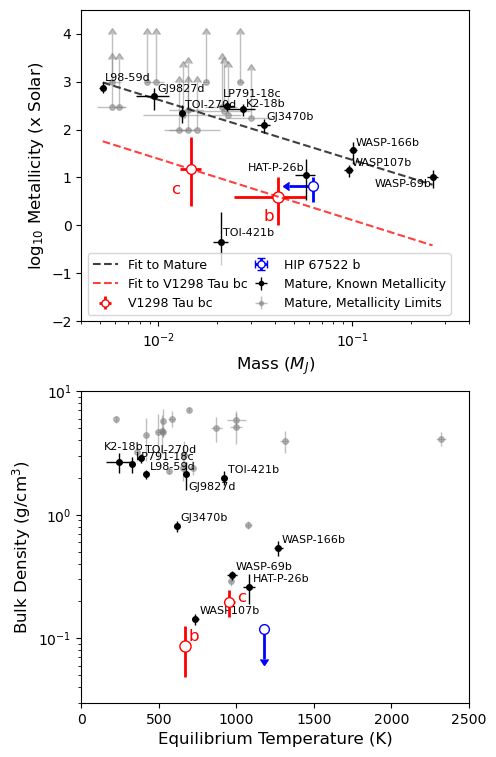

In [30]:
## DOUBLE PANEL FIGURE
fig, ax = plt.subplots(figsize=(5,9), nrows=2)
plt.subplots_adjust(hspace=0.225)
# top: Z vs mass
ax1 = ax[0]

ax1.errorbar(Mc1*Me_to_Mj, np.log10(Zc), yerr=np.resize([0.77, 0.68], (2,1)), xerr=Mc1err*Me_to_Mj, ls='None', zorder=10, elinewidth=2, lw=1, c='red', mfc='white', ms=7, marker='o', label='V1298 Tau bc')
ax1.text((Mc1-1)*Me_to_Mj, np.log10(Zc)-0.5, 'c', c='red', fontsize=12)


for i in range(len(comp_names)):
    if i == 0:
        # skip V1298 Tau c
        continue
    if comp_names[i] == 'V1298Taub':
        # ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]),  xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zloerrs[i]),np.log10(comp_Z[i]+comp_Zuperrs[i])-np.log10(comp_Z[i])], (2,1)),
        #     lw=1, ls='None', elinewidth=2, marker='o', ms=8, c='red', mfc='white') 
        ax1.errorbar(comp_masses[i]*Me_to_Mj, 0.6,  xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([0.6, 0.4], (2,1)),
            lw=1, ls='None', elinewidth=2, marker='o', ms=8, c='red', mfc='white') 
        ax1.text((comp_masses[i]-2)*Me_to_Mj, np.log10(comp_Z[i])-0.5, 'b', c='red', fontsize=12)
        continue
    if comp_names[i] == 'HIP67522b':
        # note that mass is upper limit
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=5*Me_to_Mj, xuplims=True, yerr=np.resize([np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zerrs[i]), np.log10(comp_Z[i]+comp_Zerrs[i])-np.log10(comp_Z[i])], (2,1)),
            lw=1, ls='None', elinewidth=2, marker='o', ms=7, c='blue', mfc='white', label='HIP 67522 b')
        continue
    if comp_names[i] == 'HAT-P-26b':
        # this got messed up
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(11.4), xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(11.4)-np.log10(11.4-8), np.log10(11.4+13.0)-np.log10(11.4)], (2,1)),
            lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='black')
        ax1.text(comp_masses[i]*Me_to_Mj-0.5*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.075, comp_names[i], fontsize=8, c='black')
        continue 
    if Zlims[i] == 'N':
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zerrs[i]), np.log10(comp_Z[i]+comp_Zerrs[i])-np.log10(comp_Z[i])], (2,1)),
                    lw=1, ls='None', elinewidth=1, marker='o', ms=4, zorder=2, c='black')
        if comp_names[i] == 'WASP-69b':
            ax1.text(comp_masses[i]*Me_to_Mj-0.5*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])-0.2, comp_names[i], fontsize=8, c='black')
        elif comp_names[i] == 'K2-18b':
            ax1.text(comp_masses[i]*Me_to_Mj+0.035*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.06, comp_names[i], fontsize=8, c='black')
        else:
            ax1.text(comp_masses[i]*Me_to_Mj+0.035*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.1, comp_names[i], fontsize=8, c='black')
    if Zlims[i] == 'B':
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zloerrs[i]), np.log10(comp_Z[i]+comp_Zuperrs[i])-np.log10(comp_Z[i])], (2,1)),
                    lw=1, ls='None', elinewidth=1, marker='o', ms=4, zorder=2, c='black')
        if comp_names[i] == 'LP791-18c':
            ax1.text(comp_masses[i]*Me_to_Mj-0.05*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.175, comp_names[i], fontsize=8, c='black')
        elif comp_names[i] == 'TOI-270d':
            ax1.text(comp_masses[i]*Me_to_Mj+0.035*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.1, comp_names[i], fontsize=8, c='black')
        else:
            ax1.text(comp_masses[i]*Me_to_Mj+0.025*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.15, comp_names[i], fontsize=8, c='black')
    
    if (Zlims[i] == 'L') and (comp_Z[i] > 0):
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=comp_masserrs[i]*Me_to_Mj, yerr=1, lolims=True, lw=1, zorder=1, ls='None', marker='o', ms=4, alpha=0.5, c='gray')

ax1.errorbar(0, 0, xerr=0, yerr=0, lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='black', label='Mature, Known Metallicity')
ax1.errorbar(0, 0, xerr=0, yerr=0, lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='gray', alpha=0.5, label='Mature, Metallicity Limits')

## plot linear fits:
ax1.plot(xfit, yfit_old, c='black', ls='--', alpha=0.75, zorder=3, label='Fit to Mature')
ax1.plot(xfit, yfit_v12, c='red', ls='--', alpha=0.75, zorder=3, label='Fit to V1298 Tau bc')

ax1.set_xlim(4e-3,4e-1)
ax1.set_xscale('log')
ax1.set_xlabel(r'Mass ($M_J$)', fontsize=12)
ax1.set_ylim(-2,4.5)
ax1.set_ylabel(r'log$_{10}$ Metallicity (x Solar)', fontsize=12)
ax1.legend(loc='lower left', ncol=2, fontsize=9, markerscale=0.75, columnspacing=0.1)

######################################################################################################################################
## bottom : density vs T
ax2 = ax[1]

#ax2.errorbar(comp_temps[0], comp_densities[0], xerr=comp_temperrs[0], yerr=comp_densityerrs[0], ls='None', lw=1, marker='o', ms=3, c='gray', label='Mature Exoplanets')
#ax2.errorbar(comp_temps, comp_densities, xerr=comp_temperrs, yerr=comp_densityerrs, ls='None', lw=1, marker='o', zorder=1, ms=3, c='gray')

ax2.errorbar(953, rhoc, xerr=36, yerr=rhocerr, ls='None', zorder=10, elinewidth=2, lw=1, c='red', mfc='white', ms=7, marker='o', label='V1298 Tau bc')
ax2.text(953+50, rhoc, 'c', c='red', fontsize=12)

for i in range(len(comp_names)):
    if i == 0:
        # skip V1298 Tau c
        continue
    if comp_names[i] == 'V1298Taub':
        ax2.errorbar(comp_temps[i], comp_densities[i],  xerr=comp_temperrs[i], yerr=comp_densityerrs[i], lw=1, ls='None', elinewidth=2, marker='o', ms=8, c='red', mfc='white') 
        ax2.text(comp_temps[i]+25, comp_densities[i]+(0.1*comp_densities[i]), 'b', c='red', fontsize=12)
        continue
    if comp_names[i] == 'HIP67522b':
        # note that mass is upper limit
        ax2.errorbar(comp_temps[i], comp_densities[i],  xerr=comp_temperrs[i], yerr=.05, lw=1, ls='None', uplims=True, elinewidth=2, marker='o', ms=7, c='blue', mfc='white', label='HIP 67522 b')
        continue
    if (Zlims[i] == 'N') or (Zlims[i] == 'B'):
        ax2.errorbar(comp_temps[i], comp_densities[i],  xerr=comp_temperrs[i], yerr=comp_densityerrs[i], lw=1, ls='None', elinewidth=1, zorder=4, marker='o', ms=4, c='black')
        if comp_names[i] == 'K2-18b':
            ax2.text(comp_temps[i]-100, comp_densities[i]+(0.25*comp_densities[i]), comp_names[i], fontsize=8, c='black')
        elif comp_names[i] == 'GJ9827d':
            ax2.text(comp_temps[i]+15, comp_densities[i]-(0.25*comp_densities[i]), comp_names[i], fontsize=8, c='black')
        else:
            ax2.text(comp_temps[i]+25, comp_densities[i]+(0.1*comp_densities[i]), comp_names[i], fontsize=8, c='black')
    if ((Zlims[i] == 'L') and (comp_Z[i] > 0)) or (Zlims[i] == 'Y'):
        ax2.errorbar(comp_temps[i], comp_densities[i], xerr=comp_temperrs[i], yerr=comp_densityerrs[i], lw=1, ls='None', marker='o', ms=4, zorder=1, alpha=0.5, c='gray')

ax2.set_yscale('log')
ax2.set_ylabel(r'Bulk Density (g/cm$^3$)', fontsize=12)
ax2.set_xlabel(r'Equilibrium Temperature (K)', fontsize=12)
ax2.set_ylim(0.03,10)
ax2.set_xlim(0,2500)

#ax1.plot(17.6*Me_to_Mj, np.log10(80.), marker='o', ms=4, c='purple')

plt.savefig('./figures/Figure10.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure10.pdf', format='PDF', dpi=600, bbox_inches='tight')
plt.show()